## Start-up example using composite_tools.py

In this notebook, we load the module `composite_tools.py` and use the functions therein to compute the complex moduli of the dilute spherical and dilute platelet composites.



In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import composite_tools

## Elastic endmember

First, let's consider an elastic composite with phase $1$ as the matrix and phase $2$ as the dilute inclusion.

In [2]:
# Bulk moduli (Pa)
K1 = 10e9
K2 = 30e9
# Shear moduli (Pa)
G1 = 1e9
G2 = 10e9

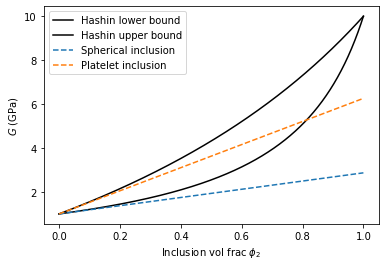

In [3]:
phi_range = np.linspace(0, 1, 1000)
Gmin, Gmax = composite_tools.G_Hashin_bounds(K1, K2, G1, G2, phi_range)

plt.plot(phi_range, Gmin / 1e9, 'k', label="Hashin lower bound")
plt.plot(phi_range, Gmax / 1e9, 'k', label="Hashin upper bound")
plt.plot(phi_range,
         composite_tools.SphericalInclusion.G(K1, G1, G2, phi_range) / 1e9,
         '--', label="Spherical inclusion")
plt.plot(phi_range,
         composite_tools.PlateletInclusion.G(K2, G1, G2, phi_range) / 1e9,
         '--', label="Platelet inclusion")

plt.xlabel(r"Inclusion vol frac $\phi_2$")
plt.ylabel(r"$G$ (GPa)")
plt.legend()

In the purely elastic case, the Hashin bounds are rigorous upper and lower bounds on the isotropic composite's elastic moduli. The composites formed by a dilute inclusion of spheres of phase $2$ or randomly oriented platelets of phase $2$ are shown superimposed on the Hashin bounds. The dilute composite moduli change linearly in the inclusion volume fraction $\phi_2$.

## Viscoelastic composites

Recognizing that for linear viscoelastic materials, a complex modulus can be used to express the viscoelastic response of the composite, we take the dilute composite formulae used above and substitute in complex moduli for phases $1$ and $2$.

Below, we provide an example of a composite viscoelastic material consisting of a dilute suspension of spherical inclusions. We select a viscoelastic matrix with shear viscosity $\eta_1$ and elastic moduli $K_1$, $G_1$. The composite bulk modulus depends also on the inclusion bulk modulus $K_2$, while the composite shear modulus depends also on the inclusion shear modulus $G_2$.

For an elastic material, the modulus is a scalar quantity. For a viscoelastic material, the complex modulus is a function of frequency; computationally, this is represented either as a callable function of frequency, or a vector of complex numbers corresponding to a discrete sample of frequencies.

In the following, we show three methods for evaluating the complex **bulk** modulus of the composite for discrete frequency samples given by `freq_vec`.

In [4]:
freq_vec = np.geomspace(1e-8, 1e1, 100)
phi2 = 0.05
eta1 = 1e14

#### Method (1/3) Plug complex shear modulus into composite formula
Use the composite formula for bulk modulus
  `K = K(K1, K2, G1, phi2)`
and plug in complex `G1` corresponding to a Maxwell material for a phase 1.

The function `mod2complex(De, G)` computes the complex shear modulus for a Maxwell material over a vector of Deborah numbers `De`. Here the Deborah number is defined with respect to the viscoelastic properties of phase $1$ only.

In [5]:
K_sweep = composite_tools.SphericalInclusion.K(K1, K2,
  composite_tools.MaxwellMaterial.mod2complex(freq_vec * eta1 / G1, G1), phi2)

#### Method (2/3) Composite bulk modulus as a mechanical circuit
By combining the two functions in Method 1, we can treat the composite bulk modulus as one big function of the frequency vector.

The function `K_complex(K1, K2, G1, eta1, phi2, freq_vec)` computes the complex shear modulus for the composite directly, given a vector of sample frequencies. Internally, the function computes the standard linear solid components corresponding to the composite, and uses these components to compute the complex bulk modulus as a function of the sample frequencies. For the parameters corresponding to each circuit component, see the source code for function `K_complex`.

In [6]:
K_complex_SLS = composite_tools.SphericalInclusion.K_complex(K1, K2, G1, eta1, phi2, freq_vec)

#### Method (3/3) Compute bulk modulus from pole-zero form
The composite bulk modulus can be represented as a rational function of frequency of the form
$$
K(i \omega) = A \frac{i\omega - z}{i\omega - p},
$$
where $A$ is the effective elastic modulus (apparent when $\omega \to \infty$), $z$ is the "zero" and $p$ is the "pole." For the composite bulk modulus, only one zero and one pole is needed.

Here, we compute the zero, pole, and constant $A$, which are all real-valued. These parameters provide additional information about the timescales of the system and the elastic modulus of the composite. From these parameters, we then compute the frequency sweep by evaluating $K(i\omega)$.

In [7]:
z, p, A = composite_tools.SphericalInclusion.K_pole_zero(K1, K2, G1, eta1, phi2) 
K_pole_zero = ((1j * freq_vec - z) / (1j * freq_vec - p) * A)

Regardless of the method, the complex modulus $K(i\omega)$ is the same. Here, we plot $|K|$ against the loss tangent $\tan \delta$ using each of the three methods.

Text(0, 0.5, '$|K|$ (GPa)')

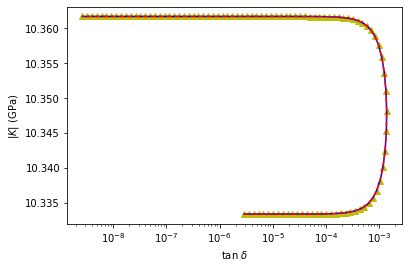

In [8]:
plt.semilogx(np.imag(K_sweep) / np.real(K_sweep),
           np.abs(K_sweep) / 1e9, 'y^')
plt.semilogx(np.imag(K_complex_SLS) / np.real(K_complex_SLS),
           np.abs(K_complex_SLS) / 1e9, 'b-')
plt.semilogx(np.imag(K_pole_zero) / np.real(K_pole_zero),
           np.abs(K_pole_zero) / 1e9, 'r--')
plt.xlabel("tan $\delta$")
plt.ylabel("$|K|$ (GPa)")

Next, we move to the shear modulus. Now, the shear viscoelasticity of the inclusion material (phase $2$) enters.

We plot the composite's stiffness in shear as $|G| / G_\mathrm{crust}$, as a function of (real) frequency. We also plot the loss tangent $\tan \delta$. Recall that $\delta \in [0, 2\pi)$ and represents the phase shift in the response relative to the forcing frequency.

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_5908\2151218868.py:23: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


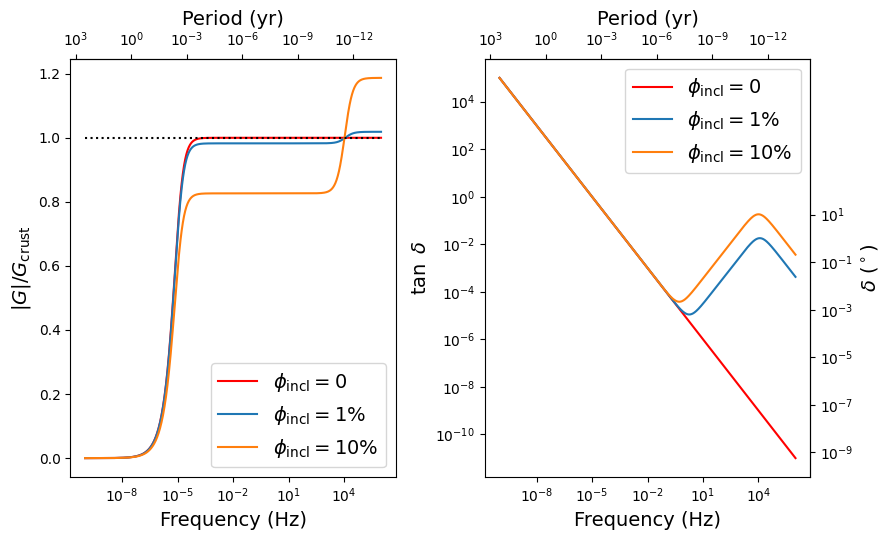

In [9]:
K1 = 10e9
K2 = 30e9
G1 = 1e9
G2 = 10e9
eta1 = 1e14
eta2 = 1e5

# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-10, 1e6, 1000) *1j
# Compute pure 1-phase complex shear modulus (0 volume fraction phase 2)
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)

# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = \
  composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = \
  composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(9,5.5), dpi=100)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.subplot(1,2,1)
plt.semilogx(np.imag(s_vec), np.abs(G1_pure) / G1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_001) / G1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.abs(G_s_010) / G1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("$|G| / G_\mathrm{crust}}$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.subplot(1,2,2)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")


plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)


plt.gca().secondary_yaxis("right", functions=(lambda x: np.arctan(x) * 180 / (np.pi),
                                              lambda x: np.tan(np.pi*x/180))).set_ylabel('$\delta$ (${}^\circ$)', fontsize=14)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")

We can play with the parameters are look at other quantities of interest, such as the imaginary component of $G$ in the following.

c:\Python39\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_5908\640914265.py:19: RuntimeWarning: divide by zero encountered in true_divide
  year2Hz = lambda t: (1 / 3.154e+7) / t


Poles are independent of phi2 in the dilute sphere suspension.


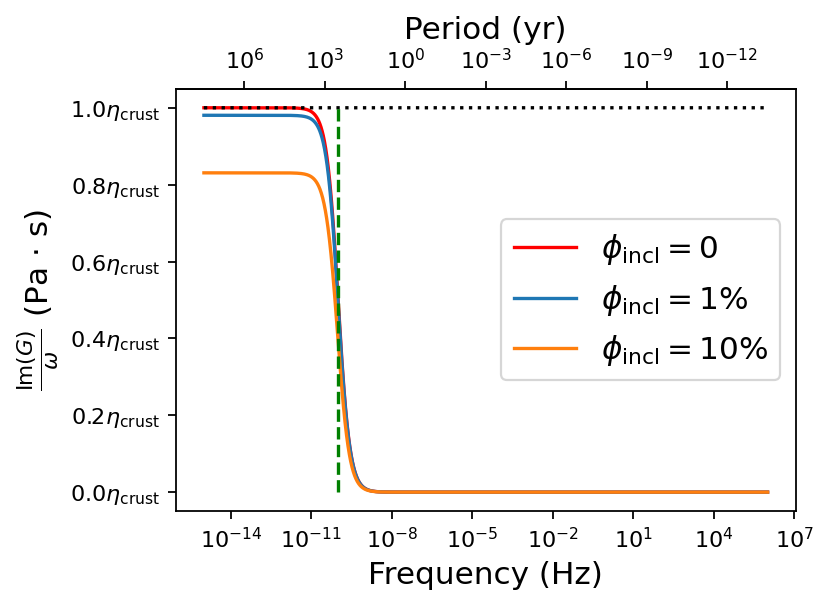

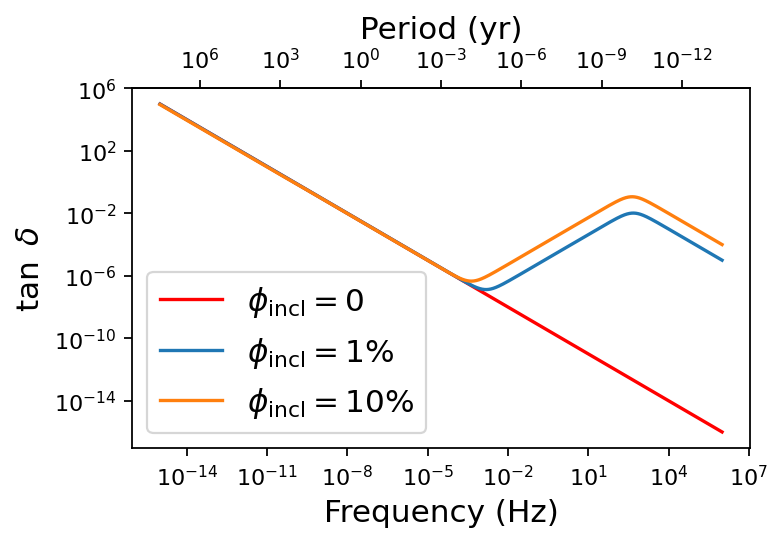

In [10]:
K1 = 10e9
K2 = 10e9
G1 = 10e9
G2 = 10e9
eta1 = 1e20
eta2 = 1e7
# Compute dimensional frequency sweep (1/s)
s_vec = np.geomspace(1e-15, 1e6, 3000) *1j
# Compute pure 1-phase complex shear modulus
G1_pure = G1 * s_vec * eta1 / (G1 + s_vec * eta1)
# Compute composite complex shear modulus
roots_num, roots_den, leading_coeff = composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.01)
G_s_001 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)
roots_num, roots_den, leading_coeff = composite_tools.SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, 0.10)
G_s_010 = leading_coeff * (s_vec - roots_num[:, np.newaxis]).prod(axis=0) / (s_vec - roots_den[:, np.newaxis]).prod(axis=0)

plt.figure(figsize=(5,3.5), dpi=160)
Hz2year = lambda t: (1 / 3.154e+7) / t
year2Hz = lambda t: (1 / 3.154e+7) / t
plt.semilogx(np.imag(s_vec), np.imag(G1_pure) / np.imag(s_vec) / eta1, 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_001) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.semilogx(np.imag(s_vec), np.imag(G_s_010) / np.imag(s_vec) / eta1, '-', label="$\phi_\mathrm{incl} = 10\%$")
plt.semilogx(np.imag(s_vec), np.ones_like(s_vec), 'k:')#, label="$1$")

plt.semilogx((G1/ eta1) * np.array([1, 1]),  np.array([0, 1]), 'g--')#, label="$1$")

plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
  lambda x, pos: f"${x:.1f} \eta_\mathrm{{crust}}$"
))

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\frac{\mathrm{Im}(G)}{\omega}$ (Pa $\cdot$ s)", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)

plt.figure(figsize=(5,3.5), dpi=160)
plt.loglog(np.imag(s_vec), np.imag(G1_pure) / np.real(G1_pure), 'r-', label="$\phi_\mathrm{incl} = 0$")
plt.loglog(np.imag(s_vec), np.imag(G_s_001) / np.real(G_s_001), '-', label="$\phi_\mathrm{incl} = 1\%$")
plt.loglog(np.imag(s_vec), np.imag(G_s_010) / np.real(G_s_010), '-', label="$\phi_\mathrm{incl} = 10\%$")

plt.legend(fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel(r"$\tan~\delta$", fontsize=14)
plt.gca().secondary_xaxis("top", functions=(Hz2year, year2Hz)).set_xlabel('Period (yr)', fontsize=14)
plt.gca().tick_params(axis='both', labelsize=10)

plt.tight_layout()

print("Poles are independent of phi2 in the dilute sphere suspension.")